# Association Rules Assignment — Market Basket Analysis

## Objective
The objective of this assignment is to apply **Association Rule Mining** using the **Apriori algorithm** on the Online Retail dataset.

Dataset used: `Online retail.xlsx`

This notebook includes:

1. Data loading  
2. Data preprocessing  
3. Missing value and duplicate handling  
4. Transaction format conversion  
5. One-hot encoded basket creation  
6. Apriori algorithm implementation  
7. Association rule generation  
8. Support, confidence, and lift threshold experiments  
9. Rule analysis and interpretation  
10. Customer purchasing behaviour insights  
11. Interview questions and answers  
12. Final conclusion

## 1. Install Required Libraries

In [5]:
# Run this cell only if libraries are missing
!pip install pandas numpy matplotlib seaborn mlxtend openpyxl

## 2. Import Required Libraries

In [6]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Association rule mining
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


# Data Preprocessing

## 3. Load Dataset

The uploaded Excel file has transactions stored row-wise.  
Each row contains comma-separated products purchased together.

In [7]:
# Load dataset without treating first row as header
df = pd.read_excel("Online retail.xlsx", header=None)

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (7501, 1)


,0
0,"shrimp,almonds,avocado,vegetables mix,green gr..."
1,"burgers,meatballs,eggs"
2,chutney
3,"turkey,avocado"
4,"mineral water,milk,energy bar,whole wheat rice..."


## 4. Basic Dataset Exploration

In [8]:
print("Dataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7501 entries, 0 to 7500
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       7501 non-null   object
dtypes: object(1)
memory usage: 58.7+ KB

Missing Values:
0    0
dtype: int64

Duplicate Rows: 2325


## 5. Rename Column

Since the dataset has one column of transaction strings, we rename it as `Transaction`.

In [9]:
df.columns = ["Transaction"]

display(df.head())

,Transaction
0,"shrimp,almonds,avocado,vegetables mix,green gr..."
1,"burgers,meatballs,eggs"
2,chutney
3,"turkey,avocado"
4,"mineral water,milk,energy bar,whole wheat rice..."


## 6. Handle Missing Values and Duplicates

Steps:
1. Remove missing transactions.
2. Remove duplicate transactions.
3. Reset index.

In [10]:
df_cleaned = df.dropna().copy()
df_cleaned = df_cleaned.drop_duplicates().reset_index(drop=True)

print("Original Shape:", df.shape)
print("Cleaned Shape:", df_cleaned.shape)

print("\nMissing Values After Cleaning:")
print(df_cleaned.isnull().sum())

display(df_cleaned.head())

Original Shape: (7501, 1)
Cleaned Shape: (5176, 1)

Missing Values After Cleaning:
Transaction    0
dtype: int64


,Transaction
0,"shrimp,almonds,avocado,vegetables mix,green gr..."
1,"burgers,meatballs,eggs"
2,chutney
3,"turkey,avocado"
4,"mineral water,milk,energy bar,whole wheat rice..."


## 7. Convert Transaction Strings into List of Items

Each transaction is split by comma.

Example:

`milk,bread,butter`

becomes:

`['milk', 'bread', 'butter']`

In [11]:
transactions = []

for transaction in df_cleaned["Transaction"]:
    items = str(transaction).split(",")
    items = [item.strip().lower() for item in items if item.strip() != ""]
    transactions.append(items)

print("Number of transactions:", len(transactions))
print("First 5 transactions:")
for i in range(5):
    print(transactions[i])

Number of transactions: 5176
First 5 transactions:
['shrimp', 'almonds', 'avocado', 'vegetables mix', 'green grapes', 'whole weat flour', 'yams', 'cottage cheese', 'energy drink', 'tomato juice', 'low fat yogurt', 'green tea', 'honey', 'salad', 'mineral water', 'salmon', 'antioxydant juice', 'frozen smoothie', 'spinach', 'olive oil']
['burgers', 'meatballs', 'eggs']
['chutney']
['turkey', 'avocado']
['mineral water', 'milk', 'energy bar', 'whole wheat rice', 'green tea']


## 8. Transaction Length Analysis

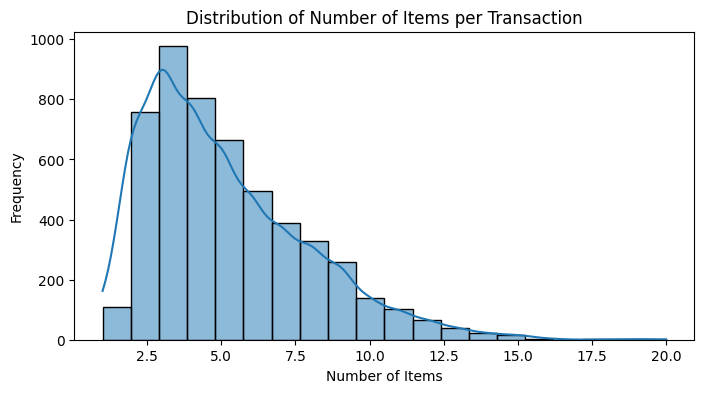

Average items per transaction: 5.07
Minimum items in a transaction: 1
Maximum items in a transaction: 20


In [12]:
transaction_lengths = [len(t) for t in transactions]

plt.figure(figsize=(8,4))
sns.histplot(transaction_lengths, bins=20, kde=True)
plt.title("Distribution of Number of Items per Transaction")
plt.xlabel("Number of Items")
plt.ylabel("Frequency")
plt.show()

print("Average items per transaction:", round(np.mean(transaction_lengths), 2))
print("Minimum items in a transaction:", np.min(transaction_lengths))
print("Maximum items in a transaction:", np.max(transaction_lengths))

## 9. Most Frequently Purchased Items

,Item,Frequency
0,mineral water,1552
1,spaghetti,1188
2,eggs,1077
3,chocolate,1063
4,french fries,997
5,milk,880
6,green tea,876
7,ground beef,703
8,frozen vegetables,672
9,pancakes,648


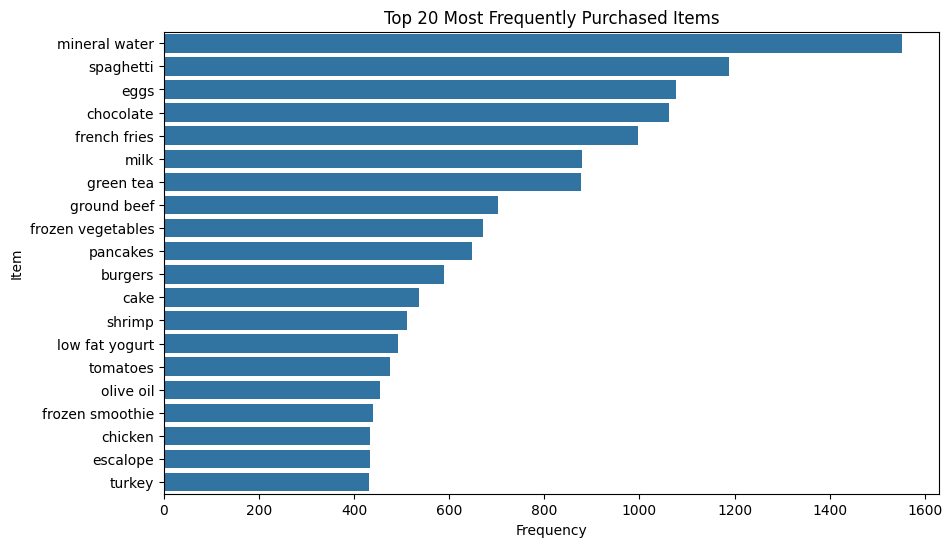

In [13]:
from collections import Counter

all_items = [item for transaction in transactions for item in transaction]
item_counts = Counter(all_items)

top_items = pd.DataFrame(item_counts.most_common(20), columns=["Item", "Frequency"])

display(top_items)

plt.figure(figsize=(10,6))
sns.barplot(data=top_items, x="Frequency", y="Item")
plt.title("Top 20 Most Frequently Purchased Items")
plt.xlabel("Frequency")
plt.ylabel("Item")
plt.show()

## 10. Convert Transactions into One-Hot Encoded Basket Format

Association rule mining requires data in a binary basket format:

- 1 / True means item was purchased in that transaction.
- 0 / False means item was not purchased in that transaction.

In [14]:
te = TransactionEncoder()

te_array = te.fit(transactions).transform(transactions)

basket_df = pd.DataFrame(te_array, columns=te.columns_)

print("Basket Data Shape:", basket_df.shape)
display(basket_df.head())

Basket Data Shape: (5176, 119)


,almonds,antioxydant juice,asparagus,avocado,babies food,bacon,barbecue sauce,black tea,blueberries,body spray,...,turkey,vegetables mix,water spray,white wine,whole weat flour,whole wheat pasta,whole wheat rice,yams,yogurt cake,zucchini
0,True,True,False,True,False,False,False,False,False,False,...,False,True,False,False,True,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,True,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False


# Association Rule Mining

## 11. Apply Apriori Algorithm

The Apriori algorithm finds frequent itemsets based on minimum support.

Support means how frequently an itemset appears in all transactions.

In [15]:
frequent_itemsets = apriori(
    basket_df,
    min_support=0.01,
    use_colnames=True
)

frequent_itemsets = frequent_itemsets.sort_values(by="support", ascending=False)

print("Number of frequent itemsets:", frequent_itemsets.shape[0])
display(frequent_itemsets.head(20))

Number of frequent itemsets: 438


,support,itemsets
54,0.299845,(mineral water)
73,0.229521,(spaghetti)
24,0.208076,(eggs)
17,0.205178,(chocolate)
30,0.192620,(french fries)
53,0.170015,(milk)
40,0.169243,(green tea)
41,0.135819,(ground beef)
36,0.129830,(frozen vegetables)
61,0.125193,(pancakes)


## 12. Generate Association Rules

Association rules are generated using frequent itemsets.

Important metrics:

- Support
- Confidence
- Lift

In [16]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.2
)

rules = rules.sort_values(by=["lift", "confidence"], ascending=False)

print("Number of association rules:", rules.shape[0])
display(rules.head(20))

Number of association rules: 356


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
300,(whole wheat pasta),(olive oil),0.040572,0.087713,0.011012,0.271429,3.094525,1.0,0.007454,1.252159,0.705471,0.093904,0.201380,0.198490
96,(herb & pepper),(ground beef),0.066461,0.135819,0.022798,0.343023,2.525588,1.0,0.013771,1.315390,0.647056,0.127018,0.239769,0.255438
320,"(shrimp, mineral water)",(frozen vegetables),0.033617,0.129830,0.010433,0.310345,2.390394,1.0,0.006068,1.261747,0.601893,0.068182,0.207448,0.195351
233,"(spaghetti, frozen vegetables)",(ground beef),0.039026,0.135819,0.012558,0.321782,2.369196,1.0,0.007257,1.274194,0.601386,0.077381,0.215190,0.207122
333,"(spaghetti, milk)",(olive oil),0.050039,0.087713,0.010240,0.204633,2.332999,1.0,0.005851,1.147002,0.601464,0.080303,0.128162,0.160687
232,"(ground beef, frozen vegetables)",(spaghetti),0.024536,0.229521,0.012558,0.511811,2.229911,1.0,0.006926,1.578240,0.565425,0.052000,0.366383,0.283262
243,"(soup, mineral water)",(milk),0.033423,0.170015,0.012365,0.369942,2.175933,1.0,0.006682,1.317315,0.559115,0.064712,0.240880,0.221335
282,"(eggs, french fries)",(burgers),0.046368,0.113794,0.011399,0.245833,2.160328,1.0,0.006122,1.175079,0.563223,0.076623,0.148994,0.173002
78,"(spaghetti, mineral water)",(ground beef),0.085008,0.135819,0.024730,0.290909,2.141885,1.0,0.013184,1.218717,0.582651,0.126108,0.179465,0.236493
322,"(frozen vegetables, mineral water)",(shrimp),0.050425,0.098918,0.010433,0.206897,2.091595,1.0,0.005445,1.136147,0.549610,0.075104,0.119832,0.156183


## 13. Clean Rules for Better Readability

Convert antecedents and consequents from frozenset format to readable strings.

In [17]:
rules_cleaned = rules.copy()

rules_cleaned["antecedents"] = rules_cleaned["antecedents"].apply(lambda x: ", ".join(list(x)))
rules_cleaned["consequents"] = rules_cleaned["consequents"].apply(lambda x: ", ".join(list(x)))

selected_columns = ["antecedents", "consequents", "support", "confidence", "lift"]

display(rules_cleaned[selected_columns].head(20))

,antecedents,consequents,support,confidence,lift
300,whole wheat pasta,olive oil,0.011012,0.271429,3.094525
96,herb & pepper,ground beef,0.022798,0.343023,2.525588
320,"shrimp, mineral water",frozen vegetables,0.010433,0.310345,2.390394
233,"spaghetti, frozen vegetables",ground beef,0.012558,0.321782,2.369196
333,"spaghetti, milk",olive oil,0.010240,0.204633,2.332999
232,"ground beef, frozen vegetables",spaghetti,0.012558,0.511811,2.229911
243,"soup, mineral water",milk,0.012365,0.369942,2.175933
282,"eggs, french fries",burgers,0.011399,0.245833,2.160328
78,"spaghetti, mineral water",ground beef,0.024730,0.290909,2.141885
322,"frozen vegetables, mineral water",shrimp,0.010433,0.206897,2.091595


## 14. Filter Strong Rules

We extract meaningful rules using thresholds:

- Support >= 0.01
- Confidence >= 0.3
- Lift >= 1.2

Lift greater than 1 indicates positive association.

In [18]:
strong_rules = rules_cleaned[
    (rules_cleaned["support"] >= 0.01) &
    (rules_cleaned["confidence"] >= 0.30) &
    (rules_cleaned["lift"] >= 1.20)
].sort_values(by=["lift", "confidence"], ascending=False)

print("Number of strong rules:", strong_rules.shape[0])
display(strong_rules[selected_columns].head(20))

Number of strong rules: 126


,antecedents,consequents,support,confidence,lift
96,herb & pepper,ground beef,0.022798,0.343023,2.525588
320,"shrimp, mineral water",frozen vegetables,0.010433,0.310345,2.390394
233,"spaghetti, frozen vegetables",ground beef,0.012558,0.321782,2.369196
232,"ground beef, frozen vegetables",spaghetti,0.012558,0.511811,2.229911
243,"soup, mineral water",milk,0.012365,0.369942,2.175933
269,"chocolate, frozen vegetables",milk,0.011592,0.350877,2.063796
311,"eggs, frozen vegetables",milk,0.010626,0.343750,2.021875
193,whole wheat pasta,milk,0.013910,0.342857,2.016623
274,"shrimp, mineral water",milk,0.011399,0.339080,1.994410
218,"eggs, ground beef",spaghetti,0.012944,0.449664,1.959144


## 15. Threshold Experiment

Different thresholds produce different numbers of rules.

- Low threshold: more rules but may include weak patterns.
- High threshold: fewer rules but stronger patterns.

,min_support,min_confidence,min_lift,number_of_rules
0,0.005,0.2,1.0,1116
1,0.005,0.2,1.2,911
2,0.005,0.2,1.5,517
3,0.005,0.3,1.0,540
4,0.005,0.3,1.2,492
5,0.005,0.3,1.5,328
6,0.005,0.4,1.0,219
7,0.005,0.4,1.2,219
8,0.005,0.4,1.5,157
9,0.010,0.2,1.0,341


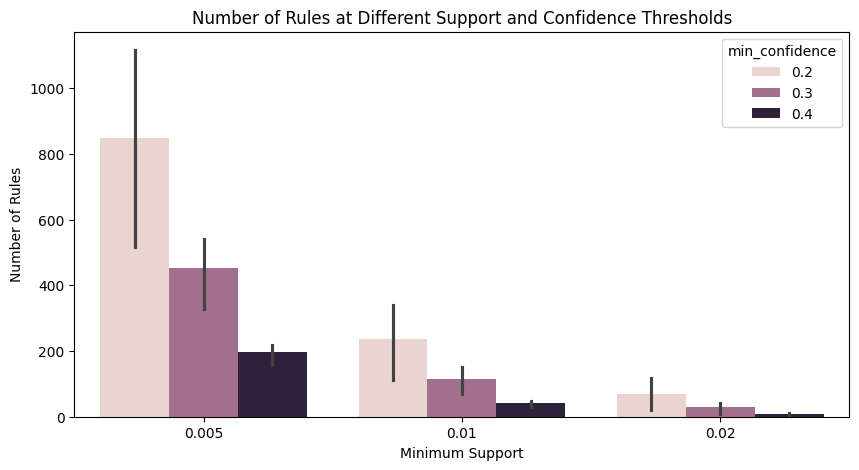

In [19]:
threshold_results = []

support_values = [0.005, 0.01, 0.02]
confidence_values = [0.2, 0.3, 0.4]
lift_values = [1.0, 1.2, 1.5]

for support in support_values:
    itemsets = apriori(basket_df, min_support=support, use_colnames=True)

    if itemsets.empty:
        continue

    for confidence in confidence_values:
        temp_rules = association_rules(itemsets, metric="confidence", min_threshold=confidence)

        for lift in lift_values:
            filtered_rules = temp_rules[temp_rules["lift"] >= lift]

            threshold_results.append({
                "min_support": support,
                "min_confidence": confidence,
                "min_lift": lift,
                "number_of_rules": len(filtered_rules)
            })

threshold_df = pd.DataFrame(threshold_results)

display(threshold_df)

plt.figure(figsize=(10,5))
sns.barplot(
    data=threshold_df,
    x="min_support",
    y="number_of_rules",
    hue="min_confidence"
)
plt.title("Number of Rules at Different Support and Confidence Thresholds")
plt.xlabel("Minimum Support")
plt.ylabel("Number of Rules")
plt.show()

# Analysis and Interpretation

## 16. Top Rules by Lift

Lift indicates how strongly two products are associated.

Higher lift means stronger relationship.

,antecedents,consequents,support,confidence,lift
96,herb & pepper,ground beef,0.022798,0.343023,2.525588
320,"shrimp, mineral water",frozen vegetables,0.010433,0.310345,2.390394
233,"spaghetti, frozen vegetables",ground beef,0.012558,0.321782,2.369196
232,"ground beef, frozen vegetables",spaghetti,0.012558,0.511811,2.229911
243,"soup, mineral water",milk,0.012365,0.369942,2.175933
269,"chocolate, frozen vegetables",milk,0.011592,0.350877,2.063796
311,"eggs, frozen vegetables",milk,0.010626,0.343750,2.021875
193,whole wheat pasta,milk,0.013910,0.342857,2.016623
274,"shrimp, mineral water",milk,0.011399,0.339080,1.994410
218,"eggs, ground beef",spaghetti,0.012944,0.449664,1.959144


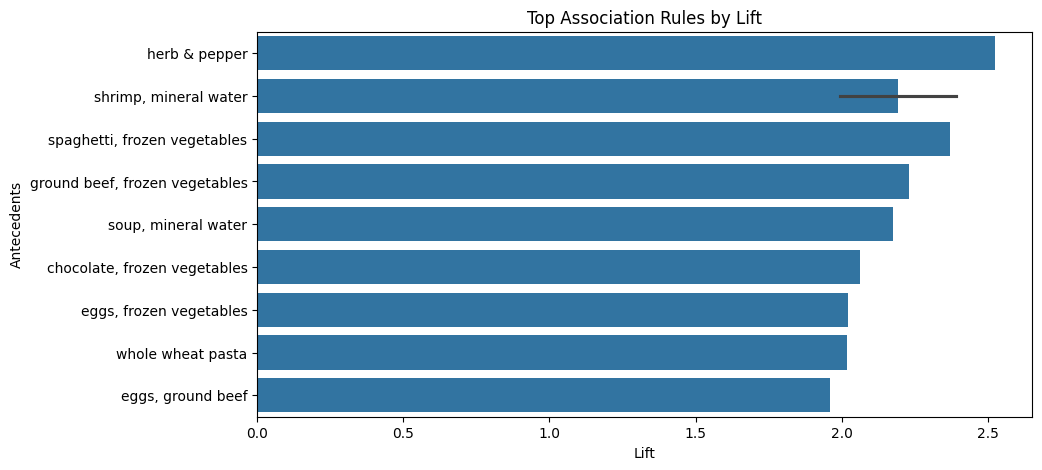

In [20]:
top_lift_rules = strong_rules.sort_values(by="lift", ascending=False).head(10)

display(top_lift_rules[selected_columns])

plt.figure(figsize=(10,5))
sns.barplot(
    data=top_lift_rules,
    x="lift",
    y="antecedents"
)
plt.title("Top Association Rules by Lift")
plt.xlabel("Lift")
plt.ylabel("Antecedents")
plt.show()

## 17. Top Rules by Confidence

Confidence means the probability that the consequent is purchased when antecedent is purchased.

,antecedents,consequents,support,confidence,lift
242,"soup, milk",mineral water,0.012365,0.576577,1.922913
207,"ground beef, frozen vegetables",mineral water,0.013331,0.543307,1.811957
302,"soup, spaghetti",mineral water,0.010819,0.523364,1.745448
305,"ground beef, pancakes",mineral water,0.010819,0.518519,1.729286
292,"chicken, chocolate",mineral water,0.011012,0.518182,1.728163
234,"olive oil, milk",mineral water,0.012365,0.512000,1.707546
232,"ground beef, frozen vegetables",spaghetti,0.012558,0.511811,2.229911
250,"olive oil, chocolate",mineral water,0.011978,0.508197,1.694862
156,"ground beef, milk",mineral water,0.016036,0.506098,1.687861
181,"eggs, ground beef",mineral water,0.014490,0.503356,1.678717


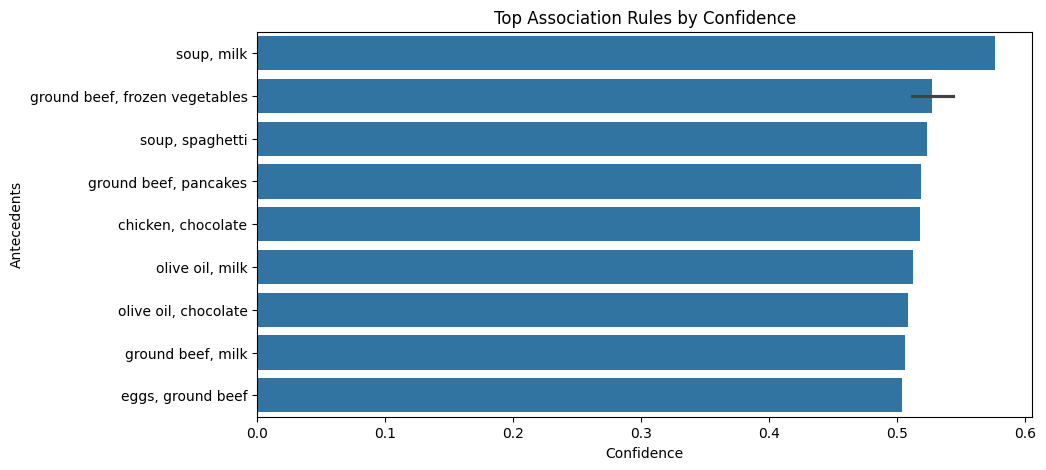

In [21]:
top_confidence_rules = strong_rules.sort_values(by="confidence", ascending=False).head(10)

display(top_confidence_rules[selected_columns])

plt.figure(figsize=(10,5))
sns.barplot(
    data=top_confidence_rules,
    x="confidence",
    y="antecedents"
)
plt.title("Top Association Rules by Confidence")
plt.xlabel("Confidence")
plt.ylabel("Antecedents")
plt.show()

## 18. Support vs Confidence Scatter Plot

This plot helps understand the relationship between support, confidence, and lift.

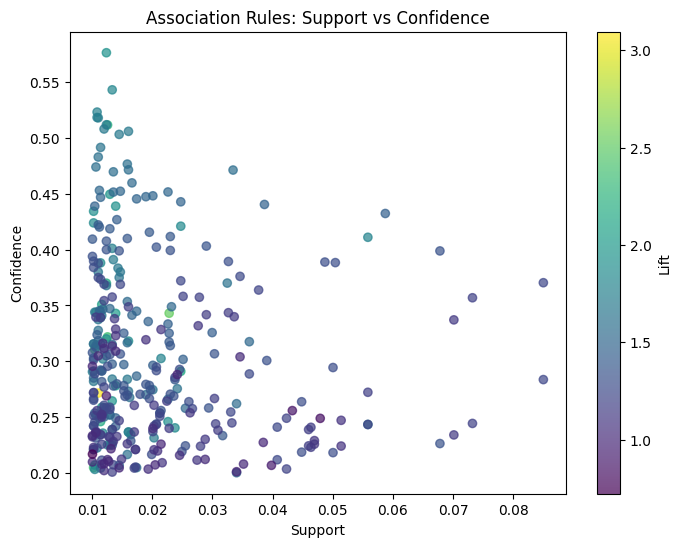

In [22]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    rules["support"],
    rules["confidence"],
    c=rules["lift"],
    alpha=0.7
)
plt.colorbar(scatter, label="Lift")
plt.title("Association Rules: Support vs Confidence")
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.show()

## 19. Customer Purchasing Behaviour Insights

Based on the association rules:

1. Products appearing together in high-lift rules have strong purchase relationships.
2. Rules with high confidence suggest useful cross-selling opportunities.
3. Frequently purchased items can be placed near associated products to increase sales.
4. Bundling products from strong rules can improve basket value.
5. Rules with high lift but low support may show niche but meaningful patterns.
6. Rules with high support indicate common purchasing patterns.

# Interview Questions

## Q1. What is Lift and why is it important in Association Rules?

Lift measures how much more likely two items are purchased together compared to being purchased independently.

Formula:

`Lift(A → B) = Confidence(A → B) / Support(B)`

Interpretation:

- Lift = 1: A and B are independent.
- Lift > 1: A and B are positively associated.
- Lift < 1: A and B are negatively associated.

### Why Lift is Important

Lift is important because confidence alone can be misleading.  
If product B is very popular, confidence may be high even if A has no real relationship with B. Lift adjusts for the popularity of B and shows the true strength of the association.

---

## Q2. What are Support and Confidence? How do you calculate them?

### Support

Support tells how frequently an itemset appears in the dataset.

Formula:

`Support(A) = Number of transactions containing A / Total number of transactions`

Example:
If milk appears in 100 transactions out of 1000:

`Support(milk) = 100 / 1000 = 0.10`

### Confidence

Confidence tells how often item B is purchased when item A is purchased.

Formula:

`Confidence(A → B) = Support(A ∪ B) / Support(A)`

Example:
If milk and bread appear together in 60 transactions and milk appears in 100 transactions:

`Confidence(milk → bread) = 60 / 100 = 0.60`

This means 60% of customers who bought milk also bought bread.

---

## Q3. What are some limitations or challenges of Association Rule Mining?

Limitations and challenges:

1. Large number of rules can be generated.
2. Many rules may be irrelevant or redundant.
3. Choosing correct support, confidence, and lift thresholds is difficult.
4. Rare but important patterns may be missed if support threshold is high.
5. Low threshold can generate too many weak rules.
6. Association rules do not prove causation.
7. Data preprocessing quality strongly affects results.
8. It can be computationally expensive for large datasets.

# Final Conclusion

In this assignment, Association Rule Mining was applied to the Online Retail dataset using the Apriori algorithm.

The dataset was preprocessed by removing missing values and duplicate transactions. Each transaction was converted into a list of products and then transformed into a one-hot encoded basket format suitable for association rule mining.

Frequent itemsets were generated using the Apriori algorithm with a minimum support threshold. Association rules were then created using confidence and lift metrics. Strong rules were filtered using support, confidence, and lift thresholds.

The generated rules helped identify relationships between products that are frequently purchased together. These insights can be used for market basket analysis, product placement, cross-selling, promotional offers, and bundle recommendations.

Overall, association rule mining is a useful technique for understanding customer purchasing behaviour, but careful threshold selection and rule interpretation are necessary to obtain meaningful business insights.